### Outlier detection using the percentile method
* uses  percentile method (threshold)
* fix a amount (1%, 99%) of percentile, the above or belove the limit will be outliers
* removal of outliers
* capping knows as Winsorization(replacing outlier by min, max values)

In [14]:
import numpy as np
import pandas as pd
import seaborn as sns

In [8]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\weight-height.csv')

In [9]:
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [10]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [11]:
df.shape

(10000, 3)

In [13]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

C:\Users\rajku\AppData\Local\Temp\ipykernel_10268\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

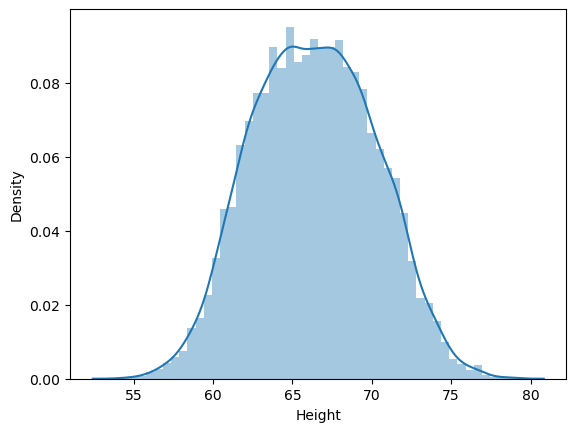

In [15]:
sns.distplot(df['Height'])

<Axes: ylabel='Height'>

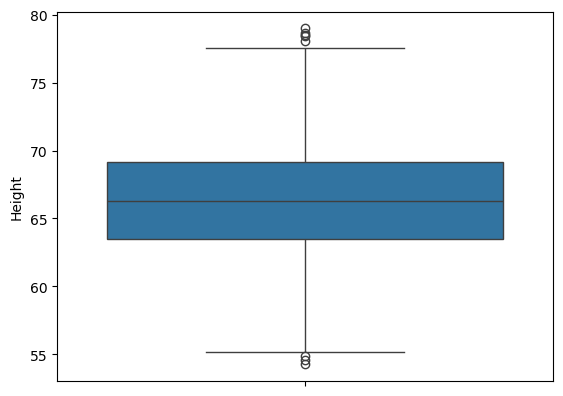

In [16]:
sns.boxplot(df['Height'])

In [17]:
upper = df['Height'].quantile(.99)
upper

np.float64(74.7857900583366)

In [18]:
lower = df['Height'].quantile(.01)
lower

np.float64(58.13441158671655)

In [33]:
new_df = df[(df['Height']>=lower) & (df['Height']<= upper)]
new_df.shape

(9800, 3)

In [34]:
new_df['Height'].describe()

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

C:\Users\rajku\AppData\Local\Temp\ipykernel_10268\3945773010.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

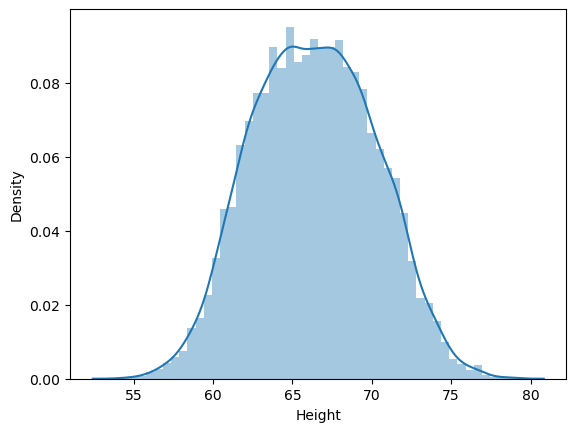

In [36]:
sns.distplot(df['Height'])

C:\Users\rajku\AppData\Local\Temp\ipykernel_10268\1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

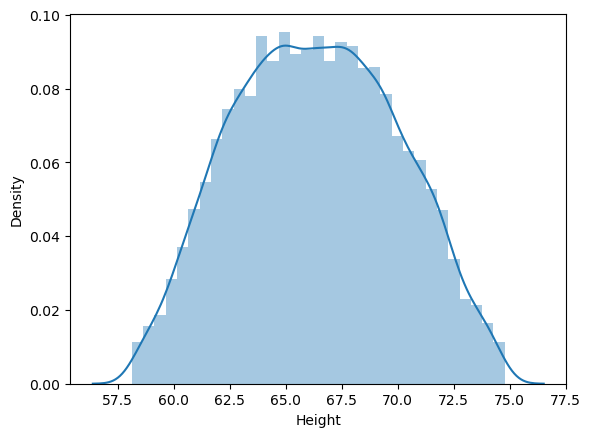

In [37]:
sns.distplot(new_df['Height'])

In [38]:
# winsorization
df['Height'] = np.where(df['Height']>= upper, upper,
np.where(df['Height']<lower, lower,
         lower))

In [39]:
df.shape

(10000, 3)

In [40]:
df['Height'].describe()

count    10000.000000
mean        58.300925
std          1.656874
min         58.134412
25%         58.134412
50%         58.134412
75%         58.134412
max         74.785790
Name: Height, dtype: float64

C:\Users\rajku\AppData\Local\Temp\ipykernel_10268\1622920233.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['Height'])


<Axes: xlabel='Height', ylabel='Density'>

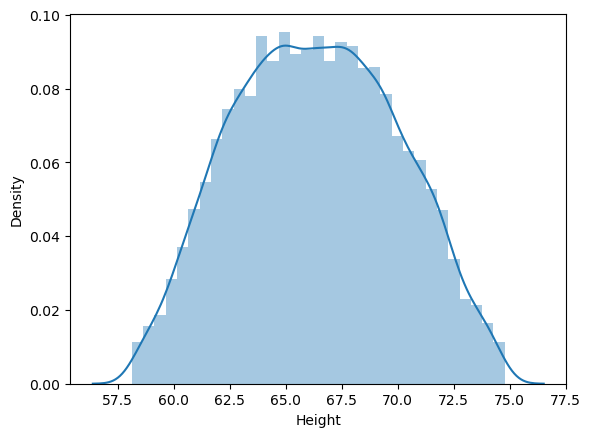

In [42]:
sns.distplot(new_df['Height'])

<Axes: ylabel='Height'>

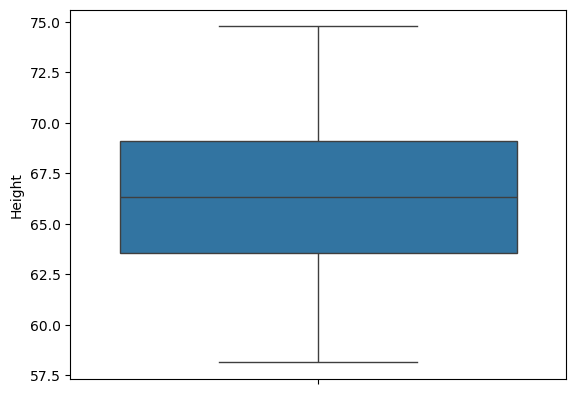

In [43]:
sns.boxplot(new_df['Height'])